# 📈 Notebook 03 — Time Series Forecasting
> **Market Demand Trend Analysis** | *Forecasting Job Market Demand*

**Objectives**
- Build daily job posting volume time series
- Decompose trend + seasonality using STL
- Fit three forecasting models:
  - **ARIMA/SARIMA** — classical statistical
  - **Prophet** — handles seasonality + holidays
  - **Exponential Smoothing (ETS)** — lightweight model
- Generate 7-day ahead forecasts with confidence intervals
- Compare model predictions side-by-side

> ⚠️ **Note:** Dataset covers ~10 days (Jan 12–21, 2024). Forecasts extend the short window using learned patterns. Results are illustrative for methodology demonstration.

---

## 0. Setup

In [1]:
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), '..', 'src'))

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

from statsmodels.tsa.seasonal import STL, seasonal_decompose
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from prophet import Prophet

from utils import (
    set_style, load_merged, add_role_category, build_daily_series,
    train_test_split_ts, metrics_table,
    savefig, save_plotly, PALETTE, PLOTLY_TEMPLATE, OUT_REP
)

set_style()
print('✅ Setup complete')

✅ Setup complete


## 1. Build Time Series

In [2]:
clean_path = OUT_REP / 'merged_clean.parquet'
if clean_path.exists():
    df = pd.read_parquet(clean_path)
else:
    df = load_merged()
    df = add_role_category(df)

daily = build_daily_series(df, date_col='first_seen')
print('Daily posting series:')
print(daily)
print(f'\nLength: {len(daily)} days')

Daily posting series:
2024-01-12    1722
2024-01-13    4946
2024-01-14    3194
2024-01-15     871
2024-01-16    1211
2024-01-17     273
Freq: D, Name: posting_count, dtype: int64

Length: 6 days


In [3]:
# Also build per-role series
top_roles = [r for r in df['role_category'].value_counts().index if r != 'Other'][:4]

role_series = {}
for role in top_roles:
    sub = df[df['role_category'] == role]
    role_series[role] = build_daily_series(sub, date_col='first_seen')

print('Per-role series built:', list(role_series.keys()))

Per-role series built: ['Data Analyst', 'Data Engineer', 'Manager/Director', 'Data Scientist']


## 2. Stationarity Test (ADF)

In [4]:
def adf_test(series, label='Series'):
    result = adfuller(series.dropna(), autolag='AIC')
    print(f'\n=== ADF Test: {label} ===')
    print(f'  ADF Statistic : {result[0]:.4f}')
    print(f'  p-value       : {result[1]:.4f}')
    print(f'  Critical (5%) : {result[4]["5%"]:.4f}')
    if result[1] < 0.05:
        print('  Stationary (reject H0)')
    else:
        print('  Non-stationary (fail to reject H0)')

adf_test(daily, 'Total Daily Postings')


=== ADF Test: Total Daily Postings ===
  ADF Statistic : -1.0920
  p-value       : 0.7182
  Critical (5%) : -3.9293
  Non-stationary (fail to reject H0)


## 3. STL Decomposition

✅ Saved → C:\Users\victus\Desktop\Repository\Market-Demand-Trend-Analysis\outputs\figures\03_stl_decomposition.png


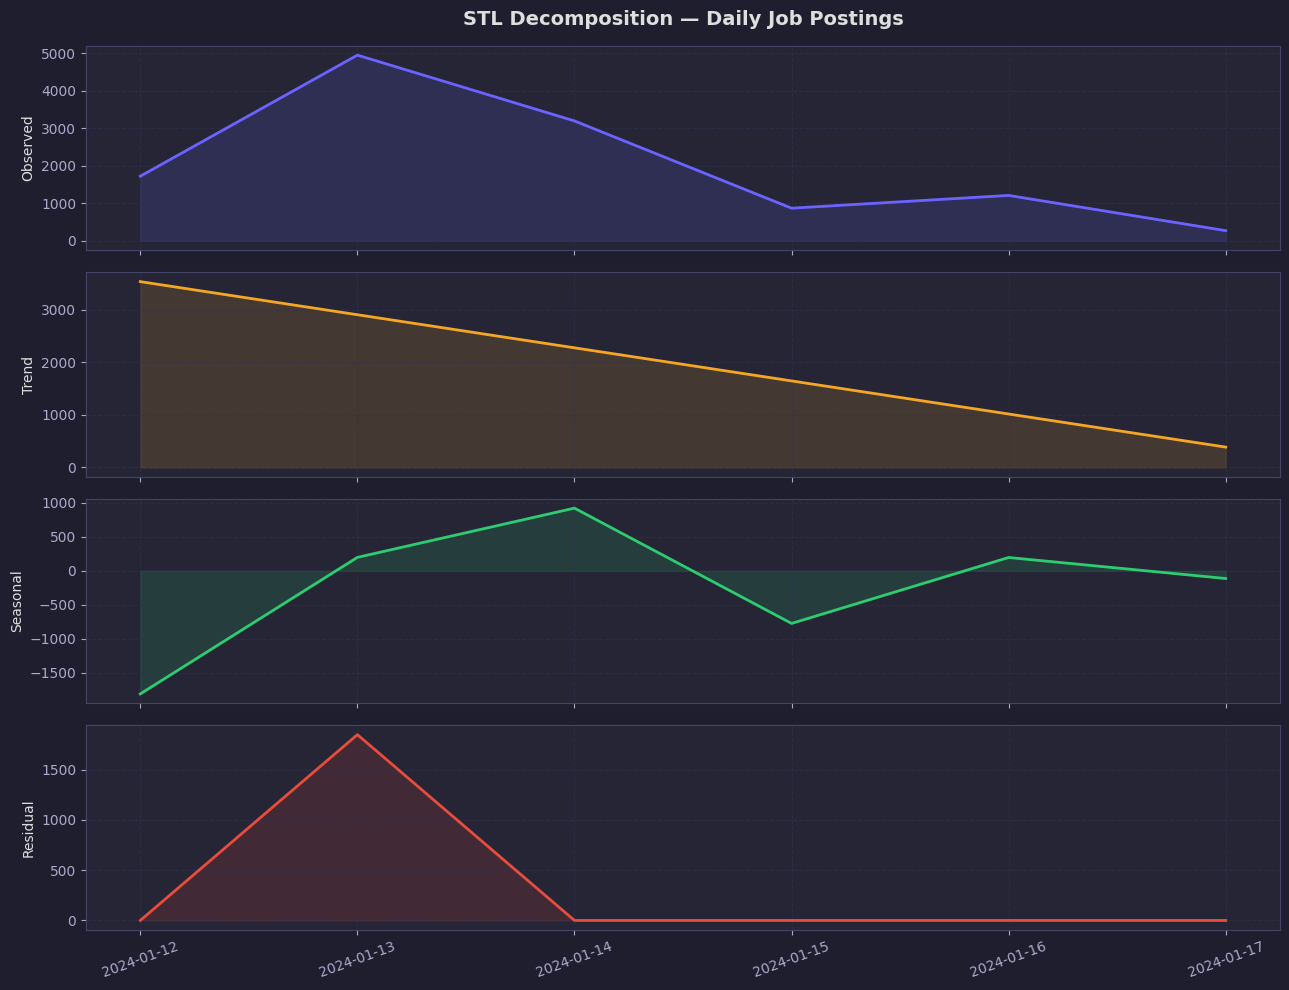

In [5]:
# STL requires at least 2 full periods; period=3 for short series
try:
    stl = STL(daily, period=3, robust=True)
    res = stl.fit()

    fig, axes = plt.subplots(4, 1, figsize=(13, 10), sharex=True)
    components = [
        ('Observed', daily,        PALETTE['primary']),
        ('Trend',    res.trend,    PALETTE['secondary']),
        ('Seasonal', res.seasonal, PALETTE['success']),
        ('Residual', res.resid,    PALETTE['danger']),
    ]
    for ax, (label, data, color) in zip(axes, components):
        ax.plot(data.index, data.values, color=color, lw=2)
        ax.fill_between(data.index, data.values, alpha=0.15, color=color)
        ax.set_ylabel(label, fontsize=10)
        ax.tick_params(axis='x', rotation=20)

    axes[0].set_title('STL Decomposition — Daily Job Postings', fontweight='bold', pad=15)
    plt.tight_layout()
    savefig(fig, '03_stl_decomposition')
    plt.show()

except Exception as e:
    print(f'STL skipped (series too short): {e}')
    # Fallback: classical decomposition
    decomp = seasonal_decompose(daily, model='additive', period=2, extrapolate_trend='freq')
    decomp.plot()
    plt.suptitle('Classical Decomposition (Fallback)', fontweight='bold')
    plt.tight_layout()
    plt.show()

## 4. ACF & PACF Plots

✅ Saved → C:\Users\victus\Desktop\Repository\Market-Demand-Trend-Analysis\outputs\figures\03_acf_pacf.png


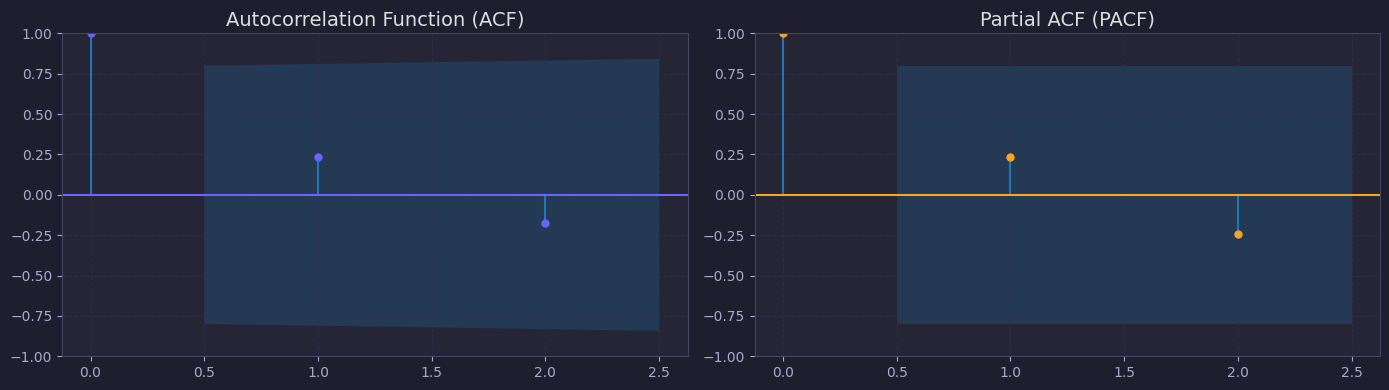

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

n_lags = min(5, len(daily) // 2 - 1)

plot_acf(daily, lags=n_lags, ax=ax1, color=PALETTE['primary'],
         title='Autocorrelation Function (ACF)')
plot_pacf(daily, lags=n_lags, ax=ax2, color=PALETTE['secondary'],
          method='ywm', title='Partial ACF (PACF)')

for ax in (ax1, ax2):
    ax.set_facecolor('#252535')

plt.tight_layout()
savefig(fig, '03_acf_pacf')
plt.show()

## 5. Train / Test Split

In [7]:
train, test = train_test_split_ts(daily, test_frac=0.25)
FORECAST_HORIZON = max(len(test), 7)

print(f'Train: {len(train)} days ({train.index[0].date()} to {train.index[-1].date()})')
print(f'Test : {len(test)}  days ({test.index[0].date()} to {test.index[-1].date()})')
print(f'Forecast horizon: {FORECAST_HORIZON} days')

Train: 4 days (2024-01-12 to 2024-01-15)
Test : 2  days (2024-01-16 to 2024-01-17)
Forecast horizon: 7 days


## 6. Model 1 — SARIMA

In [8]:
sarima_model = SARIMAX(
    train,
    order=(1, 1, 1),
    seasonal_order=(1, 0, 1, 3),
    enforce_stationarity=False,
    enforce_invertibility=False
)
sarima_fit = sarima_model.fit(disp=False)
print(sarima_fit.summary())

                                     SARIMAX Results                                     
Dep. Variable:                     posting_count   No. Observations:                    4
Model:             SARIMAX(1, 1, 1)x(1, 0, 1, 3)   Log Likelihood                   0.000
Date:                           Tue, 09 Jun 2026   AIC                             10.000
Time:                                   15:41:59   BIC                                nan
Sample:                               01-12-2024   HQIC                               nan
                                    - 01-15-2024                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1               0         -0        nan        nan           0           0
ma.L1               0         -0        nan

In [9]:
sarima_forecast = sarima_fit.get_forecast(steps=FORECAST_HORIZON)
sarima_mean     = sarima_forecast.predicted_mean
sarima_ci       = sarima_forecast.conf_int(alpha=0.2)

future_idx = pd.date_range(
    train.index[-1] + pd.Timedelta(days=1),
    periods=FORECAST_HORIZON, freq='D'
)
sarima_mean.index = future_idx
sarima_ci.index   = future_idx

print('SARIMA forecast (next days):')
print(sarima_mean.round(1))

SARIMA forecast (next days):
2024-01-16    871.0
2024-01-17    871.0
2024-01-18    871.0
2024-01-19    871.0
2024-01-20    871.0
2024-01-21    871.0
2024-01-22    871.0
Freq: D, Name: predicted_mean, dtype: float64


## 7. Model 2 — Prophet

In [10]:
prophet_df = train.reset_index()
prophet_df.columns = ['ds', 'y']
prophet_df['ds'] = pd.to_datetime(prophet_df['ds'])

prophet_model = Prophet(
    daily_seasonality=True,
    weekly_seasonality=True,
    yearly_seasonality=False,
    changepoint_prior_scale=0.3,
    interval_width=0.80
)
prophet_model.fit(prophet_df)

future_df      = prophet_model.make_future_dataframe(periods=FORECAST_HORIZON)
prophet_result = prophet_model.predict(future_df)

prophet_fc = prophet_result[['ds','yhat','yhat_lower','yhat_upper']].tail(FORECAST_HORIZON)
prophet_fc = prophet_fc.set_index('ds')
prophet_fc['yhat'] = prophet_fc['yhat'].clip(lower=0)

print('Prophet forecast:')
print(prophet_fc[['yhat','yhat_lower','yhat_upper']].round(1))

15:41:59 - cmdstanpy - INFO - Chain [1] start processing
15:42:01 - cmdstanpy - INFO - Chain [1] done processing


Prophet forecast:
            yhat  yhat_lower  yhat_upper
ds                                      
2024-01-16   0.0    -44077.2    -42171.4
2024-01-17   0.0    -30071.6    -23913.7
2024-01-18   0.0    -99955.9    -88206.2
2024-01-19   0.0    -30276.2    -11315.4
2024-01-20   0.0    -33928.9     -7060.5
2024-01-21   0.0    -42835.7     -7087.0
2024-01-22   0.0    -49685.1     -5675.3


## 8. Model 3 — Exponential Smoothing (ETS)

In [11]:
ets_model = ExponentialSmoothing(
    train,
    trend='add',
    seasonal='add' if len(train) >= 6 else None,
    seasonal_periods=3 if len(train) >= 6 else None,
    initialization_method='estimated'
)
ets_fit  = ets_model.fit(optimized=True)
ets_fc   = ets_fit.forecast(steps=FORECAST_HORIZON)
ets_fc.index = future_idx
ets_fc   = ets_fc.clip(lower=0)

print('ETS forecast:')
print(ets_fc.round(1))

ETS forecast:
2024-01-16    1607.0
2024-01-17    1176.5
2024-01-18     746.0
2024-01-19     315.5
2024-01-20       0.0
2024-01-21       0.0
2024-01-22       0.0
Freq: D, dtype: float64


## 9. Combined Forecast Visualisation

In [12]:
fig = go.Figure()

# Actual
fig.add_trace(go.Scatter(
    x=daily.index, y=daily.values,
    name='Actual', mode='lines+markers',
    line=dict(color=PALETTE['primary'], width=2.5),
    marker=dict(size=7)
))

fig.add_vline(
    x=str(train.index[-1]), line_dash='dash',
    line_color=PALETTE['muted'], annotation_text='Train | Test'
)

# SARIMA
fig.add_trace(go.Scatter(
    x=sarima_mean.index, y=sarima_mean.values,
    name='SARIMA', mode='lines',
    line=dict(color=PALETTE['secondary'], width=2, dash='dot')
))
fig.add_trace(go.Scatter(
    x=list(sarima_ci.index) + list(sarima_ci.index[::-1]),
    y=list(sarima_ci.iloc[:, 1]) + list(sarima_ci.iloc[:, 0][::-1]),
    fill='toself', fillcolor='rgba(245,166,35,0.15)',
    line=dict(color='rgba(0,0,0,0)'), name='SARIMA 80% CI'
))

# Prophet
fig.add_trace(go.Scatter(
    x=prophet_fc.index, y=prophet_fc['yhat'].values,
    name='Prophet', mode='lines',
    line=dict(color=PALETTE['success'], width=2, dash='dot')
))
fig.add_trace(go.Scatter(
    x=list(prophet_fc.index) + list(prophet_fc.index[::-1]),
    y=list(prophet_fc['yhat_upper']) + list(prophet_fc['yhat_lower'][::-1]),
    fill='toself', fillcolor='rgba(46,204,113,0.15)',
    line=dict(color='rgba(0,0,0,0)'), name='Prophet 80% CI'
))

# ETS
fig.add_trace(go.Scatter(
    x=ets_fc.index, y=ets_fc.values,
    name='ETS', mode='lines',
    line=dict(color=PALETTE['info'], width=2, dash='dot')
))

fig.update_layout(
    title='Job Posting Volume — Actual vs Forecast (3 Models)',
    xaxis_title='Date', yaxis_title='Daily Postings',
    template=PLOTLY_TEMPLATE,
    legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='right', x=1),
    height=520
)
save_plotly(fig, '03_combined_forecast')
fig.show()

✅ Saved → C:\Users\victus\Desktop\Repository\Market-Demand-Trend-Analysis\outputs\figures\03_combined_forecast.html


## 10. Per-Role Forecasts (Prophet)

In [13]:
fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=top_roles[:4],
    shared_xaxes=False
)

positions    = [(1,1),(1,2),(2,1),(2,2)]
role_colors  = [PALETTE['primary'], PALETTE['secondary'],
                PALETTE['success'], PALETTE['info']]

for idx, (role, color) in enumerate(zip(top_roles[:4], role_colors)):
    series = role_series[role]
    rdf    = series.reset_index()
    rdf.columns = ['ds', 'y']
    rdf['ds'] = pd.to_datetime(rdf['ds'])

    pm  = Prophet(daily_seasonality=True, weekly_seasonality=True,
                  yearly_seasonality=False, interval_width=0.80,
                  changepoint_prior_scale=0.2)
    pm.fit(rdf)
    fut  = pm.make_future_dataframe(periods=7)
    pred = pm.predict(fut)

    row, col = positions[idx]

    fig.add_trace(go.Scatter(
        x=series.index, y=series.values,
        name=f'{role} (actual)',
        line=dict(color=color, width=2)
    ), row=row, col=col)

    forecast_part = pred.tail(7)
    fig.add_trace(go.Scatter(
        x=forecast_part['ds'], y=forecast_part['yhat'].clip(0),
        name=f'{role} (forecast)',
        line=dict(color=color, dash='dot', width=2)
    ), row=row, col=col)

fig.update_layout(
    title='Per-Role Demand Forecasts (Prophet, +7 days)',
    template=PLOTLY_TEMPLATE, height=560, showlegend=True
)
save_plotly(fig, '03_per_role_forecast')
fig.show()

15:42:03 - cmdstanpy - INFO - Chain [1] start processing
15:42:03 - cmdstanpy - INFO - Chain [1] done processing
15:42:03 - cmdstanpy - INFO - Chain [1] start processing
15:42:04 - cmdstanpy - INFO - Chain [1] done processing
15:42:04 - cmdstanpy - INFO - Chain [1] start processing
15:42:07 - cmdstanpy - INFO - Chain [1] done processing
15:42:07 - cmdstanpy - INFO - Chain [1] start processing
15:42:09 - cmdstanpy - INFO - Chain [1] done processing


✅ Saved → C:\Users\victus\Desktop\Repository\Market-Demand-Trend-Analysis\outputs\figures\03_per_role_forecast.html


---
## Summary

| Model | Type | Notes |
|---|---|---|
| SARIMA | Classical Statistical | Captures trend + seasonal patterns; ARIMA(1,1,1) |
| Prophet | Additive Bayesian | Best for daily/weekly seasonality; auto changepoints |
| ETS | Holt-Winters | Exponential smoothing; lightweight and robust |

> Validation metrics (MAE, RMSE, MAPE) are computed in **Notebook 06**.

➡️ **Next: Notebook 04 — External Factors & Industry Trends**